## Imports

In [1]:
import pysimdamicm

import ROOT

import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt

In [112]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.measure import label, regionprops

In [113]:
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"

### Helpers

In [114]:
def plot_cluster_gallery_on_frame(idx_yx, result, ccd_shape, max_points_per_cluster=None):
    """
    Plot the cluster gallery for a single (best) result.
    Each panel shows the FULL CCD frame, with only that cluster overplotted.
    
    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    max_points_per_cluster : optional cap on points per cluster
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 6 * nrows),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — full-frame view", y=0.98)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k // ncols][k % ncols]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        # plot cluster points on full CCD frame
        ax.scatter(x_all[sel], y_all[sel], s=2)

        ax.set_xlim(0, W)
        ax.set_ylim(0, H)
        ax.set_aspect("equal", "box")

        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    for kk in range(K, nrows * ncols):
        axes[kk // ncols][kk % ncols].axis("off")

    plt.tight_layout()
    plt.show()

In [115]:
def plot_clusters_on_frame(idx_yx, result, ccd_shape, clusters_to_show=None,
                            max_points_per_cluster=None, cmap_name="tab10",
                            figsize=(8, 8), point_size=2):
    """
    Plot selected clusters on a single full CCD frame, each in a different color.

    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    clusters_to_show : iterable of cluster indices to plot (e.g. [0, 1, 2, 3]).
        If None, all clusters are shown.
    max_points_per_cluster : optional cap on points per cluster
    cmap_name : matplotlib colormap name (qualitative recommended)
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    if clusters_to_show is None:
        clusters_to_show = list(range(K))
    else:
        clusters_to_show = list(clusters_to_show)
        bad = [k for k in clusters_to_show if k < 0 or k >= K]
        if bad:
            raise ValueError(f"Invalid cluster indices {bad}; valid range is 0..{K-1}")

    cmap = plt.get_cmap(cmap_name)
    rng = np.random.default_rng(209)

    fig, ax = plt.subplots(figsize=figsize)

    for i, k in enumerate(clusters_to_show):
        sel = (labels == k)
        if not sel.any():
            continue

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        color = cmap(i % cmap.N)
        ax.scatter(x_all[sel], y_all[sel], s=point_size,
                   color=color, label=f"Cluster {k}")

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x (col)")
    ax.set_ylabel("y (row)")
    ax.set_title(f"GMM clusters (showing {len(clusters_to_show)} of K={K})")

    leg = ax.legend(markerscale=4, loc="upper left", bbox_to_anchor=(1.01, 1), framealpha=0.9)
    for handle in leg.legend_handles:
        handle.set_sizes([30])

    plt.tight_layout()
    plt.show()

In [116]:
def make_samples(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses raw E (no log) as the third feature.

    Returns:
      X_raw : (N,3) with columns [y, x, E]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    X_raw = np.column_stack([ys, xs, E])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

Fit GMM

In [117]:
REG_COVAR = 1e-6
RANDOM_STATE = 209

def _unscale_covariances(gmm, scaler):
    """
    Map covariances from standardized space back to original feature space.
    Handles only covariance_type='full' (what you're using).
    """
    if gmm.covariance_type != "full":
        raise ValueError("This helper currently assumes covariance_type='full'.")

    D = np.diag(scaler.scale_)
    covs_std = gmm.covariances_                 # shape: (K, d, d)
    covs_raw = np.empty_like(covs_std)
    for k in range(covs_std.shape[0]):
        covs_raw[k] = D @ covs_std[k] @ D       # Σ_raw = D Σ_std D
    return covs_raw

def fit_gmms_over_K(X_raw, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE):
    """
    Standardize features, fit a full-covariance GMM for each K.
    Returns: list of dicts with model, labels, BIC, AIC, scaler, and
             means/covariances mapped back to ORIGINAL units.
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_raw)

    results = []
    for K in K_RANGE:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            reg_covar=reg_covar,
            random_state=random_state
        )
        gmm.fit(X_std)

        # Predict labels in standardized space, but keep for reference
        labels = gmm.predict(X_std)

        # --- NEW: parameters in original (unscaled) space ---
        means_raw = scaler.inverse_transform(gmm.means_)       # shape: (K, d)
        covs_raw  = _unscale_covariances(gmm, scaler)          # shape: (K, d, d)

        bic = gmm.bic(X_std)
        aic = gmm.aic(X_std)
        results.append({
            "K": K,
            "model": gmm,
            "labels": labels,         # labels on the standardized X
            "bic": bic,
            "aic": aic,
            "scaler": scaler,
            "means_raw": means_raw,   # <-- in original units
            "covs_raw": covs_raw      # <-- in original units
        })

    results.sort(key=lambda r: r["bic"])
    return results

Plotting options

In [118]:
from matplotlib.colors import ListedColormap

def plot_one_cluster(idx_yx, result, ccd_shape, cluster_id, origin="lower"):
    """
    imshow-style plot (like your example) but only for a single cluster_id.
    """
    H, W = ccd_shape
    labels = np.asarray(result["labels"])

    # pick points for this cluster
    sel = (labels == cluster_id)
    ys = np.asarray(idx_yx[:, 0], dtype=int)[sel]
    xs = np.asarray(idx_yx[:, 1], dtype=int)[sel]

    # make a 0/1 image for this cluster only
    img = np.zeros((H, W), dtype=np.uint8)
    img[ys, xs] = 1

    # colormap: background white, cluster blue (change if you want)
    cmap = ListedColormap(["white", "#1f77b4"])

    plt.figure(figsize=(12, 8))
    plt.imshow(img, origin=origin, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"GMM Cluster {cluster_id}")
    plt.xlabel("Column index (x)")
    plt.ylabel("Row index (y)")
    plt.tight_layout()
    plt.show()


### Pull waders calibrated image

In [174]:
fits_path = "/home/dsalma/damicm-ml/science_run_data/cut_img/compose_103_ccdA_cut_6300x8000.fits"

with fits.open(fits_path) as hdul:
    hdul.info()

Filename: /home/dsalma/damicm-ml/science_run_data/cut_img/compose_103_ccdA_cut_6300x8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  CALIBRATED    1 PrimaryHDU     144   (6300, 8000)   float64   
  1  COMPRESSED_IMAGE    1 CompImageHDU      7   (6300, 8000)   int64   


In [175]:
with fits.open(fits_path) as hdul:
    cal_img = hdul[0].data

In [176]:
print("shape:", cal_img.shape)
print("type:", type(cal_img))
print("dtype:", cal_img.dtype)

shape: (8000, 6300)
type: <class 'numpy.ndarray'>
dtype: >f8


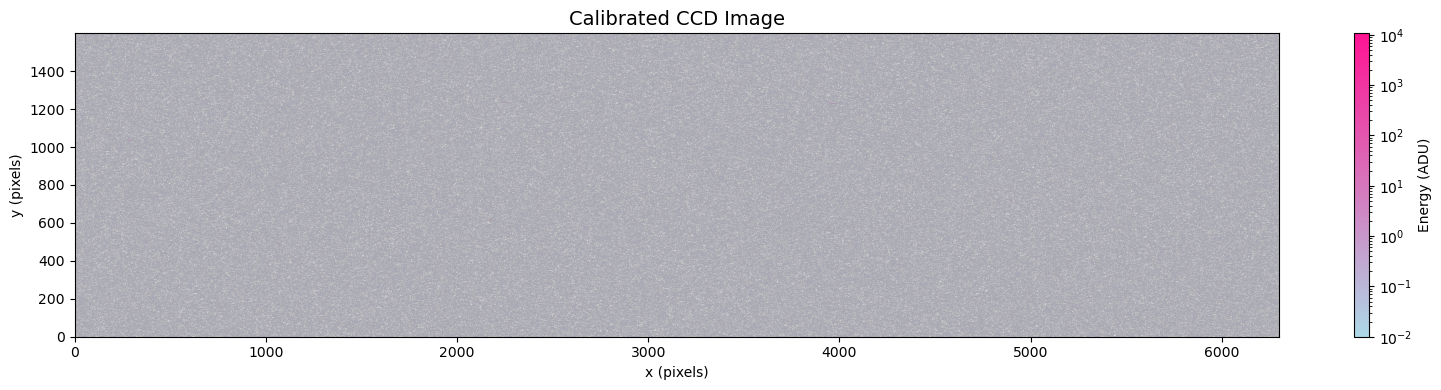

In [122]:
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list('custom', ['lightblue', 'deeppink'])

plt.figure(figsize=(16, 4))
plt.imshow(cal_img, aspect='auto', origin='lower', cmap=custom_cmap,
           norm=colors.LogNorm(vmin=max(cal_img[cal_img > 0].min(), 1e-3), vmax=cal_img.max()))
plt.colorbar(label='Energy (ADU)')
plt.title('Calibrated CCD Image', fontsize=14)
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.tight_layout()
plt.show()

### GMM analysis

In [177]:
K_RANGE = [2,3,4,5,6]

In [ ]:
# build samples
X_raw_cut, idx_yx = make_samples(cal_img)

In [ ]:
results_cut = fit_gmms_over_K(X_raw_cut, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE)

In [157]:
best = results_cut[0]

In [158]:
from matplotlib.colors import ListedColormap

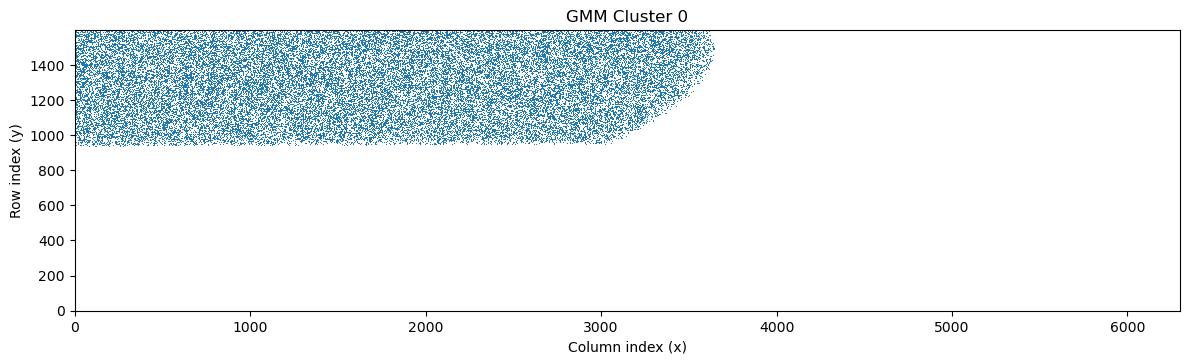

In [159]:
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=0)


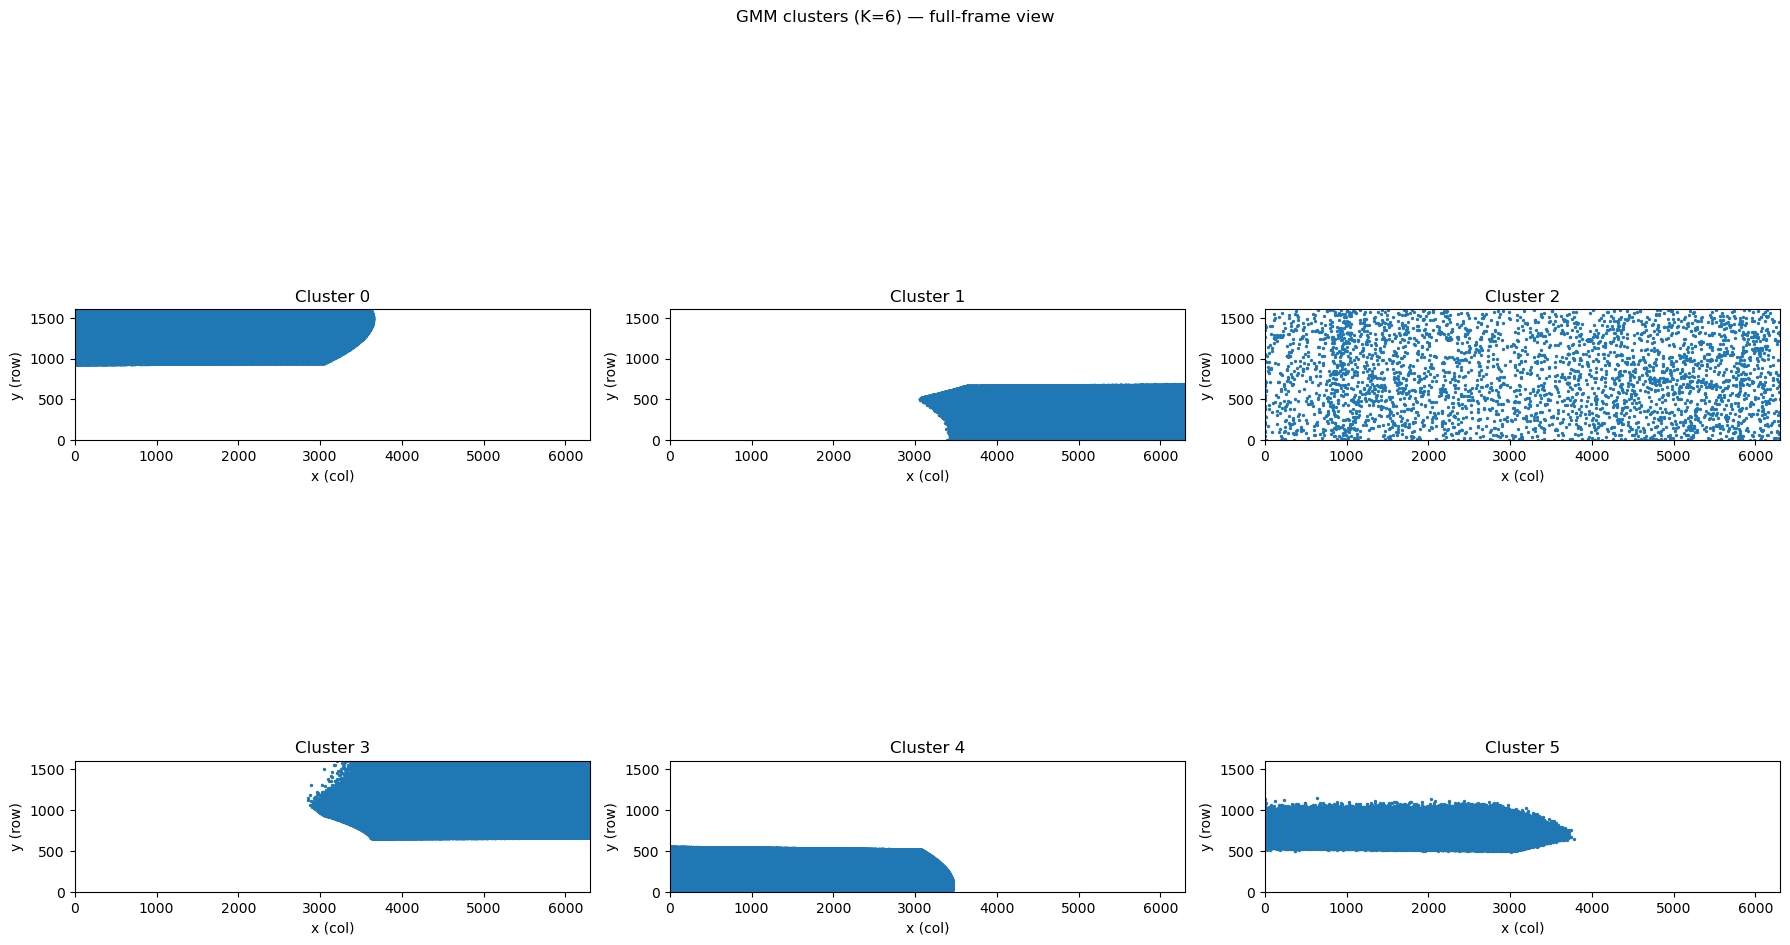

In [160]:
plot_cluster_gallery_on_frame(idx_yx, best, ccd_shape=cal_img.shape)

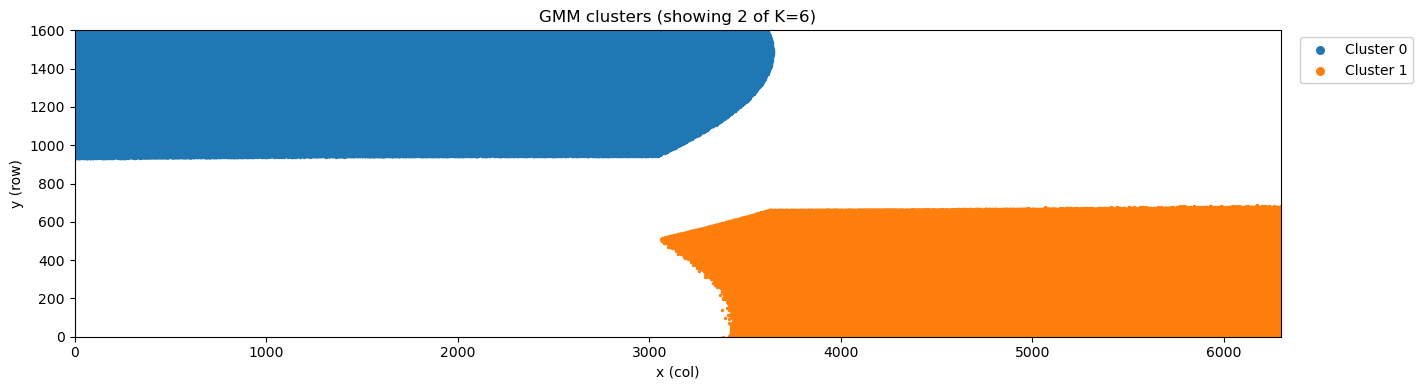

In [161]:
plot_clusters_on_frame(idx_yx, best, ccd_shape=cal_img.shape, clusters_to_show=[0, 1], figsize=(24,4))

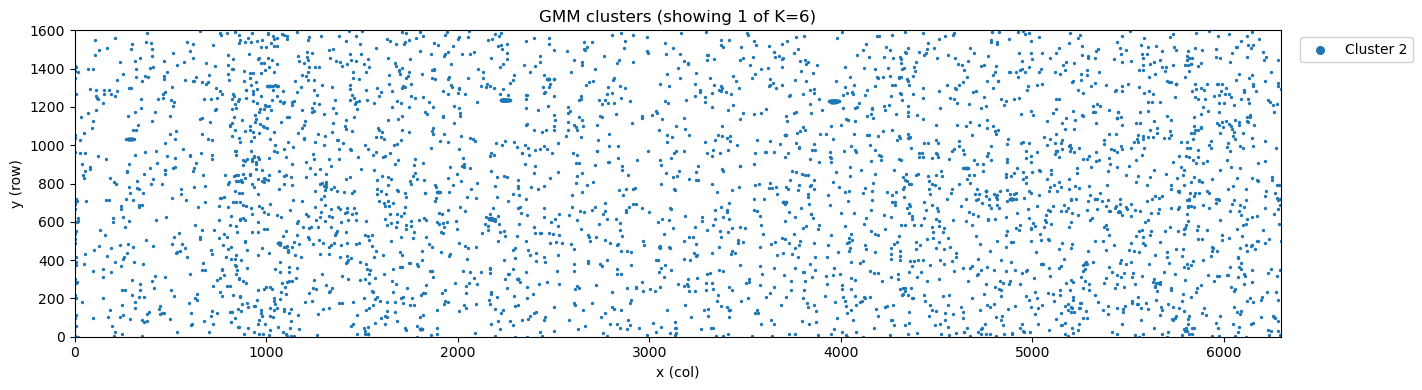

In [162]:
plot_clusters_on_frame(idx_yx, best, ccd_shape=cal_img.shape, clusters_to_show=[2], figsize=(24,4))

In [155]:
def cluster_energy_extrema(idx_yx, energies, result, clusters_to_show=None):
    """
    Find the highest and lowest energy pixel in each cluster.

    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    energies : (N,) array of energy values at those pixels
    result : dict with keys "K" and "labels"
    clusters_to_show : iterable of cluster indices. If None, all clusters.

    Returns
    -------
    dict mapping cluster index -> {"min": ..., "max": ...}
    """
    labels = result["labels"]
    K = result["K"]

    if clusters_to_show is None:
        clusters_to_show = list(range(K))

    out = {}
    for k in clusters_to_show:
        sel = np.flatnonzero(labels == k)
        if sel.size == 0:
            out[k] = None
            continue

        e_k = energies[sel]
        i_min = sel[np.argmin(e_k)]
        i_max = sel[np.argmax(e_k)]

        out[k] = {
            "min": {"yx": (int(idx_yx[i_min, 0]), int(idx_yx[i_min, 1])),
                    "energy": float(energies[i_min])},
            "max": {"yx": (int(idx_yx[i_max, 0]), int(idx_yx[i_max, 1])),
                    "energy": float(energies[i_max])},
        }
    return out

In [156]:
# --- usage ---
energies = cal_img[idx_yx[:, 0], idx_yx[:, 1]]
extrema = cluster_energy_extrema(idx_yx, energies, best, clusters_to_show=[0, 1, 2])

for k, v in extrema.items():
    print(f"Cluster {k}: "
          f"min={v['min']['energy']:.3f} at {v['min']['yx']}, "
          f"max={v['max']['energy']:.3f} at {v['max']['yx']}")

Cluster 0: min=0.010 at (733, 105), max=0.650 at (1151, 1923)
Cluster 1: min=0.010 at (0, 4), max=0.660 at (124, 1687)
Cluster 2: min=0.640 at (688, 3944), max=10676.250 at (617, 2165)


In [163]:
import numpy as np
from scipy.ndimage import label as cc_label

def blobs_from_gmm(X_raw, gmm_labels, frame_size, cluster_id):
    """
    X_raw      : (N,3) array [y, x, E]
    gmm_labels : (N,) GMM labels (same order as X_raw)
    frame_size : (H, W)
    cluster_id : GMM component to extract

    Returns:
      blobs   : dict {blob_id: array [[y,x,E], ...]}
      labeled : (H,W) blob-ID image
    """
    H, W = frame_size

    sel = (gmm_labels == cluster_id)
    if not np.any(sel):
        labeled = np.zeros((H, W), dtype=int)
        return {}, labeled

    y = X_raw[sel, 0].astype(int)
    x = X_raw[sel, 1].astype(int)
    E = X_raw[sel, 2].astype(float)

    img = np.zeros((H, W), dtype=np.uint8)
    img[y, x] = 1

    # HARD-CODED 8-connectivity
    labeled = cc_label(img, structure=np.ones((3, 3), dtype=int))[0]

    blob_ids = labeled[y, x]
    blobs = {}

    for bid in np.unique(blob_ids):
        if bid == 0:
            continue
        m = (blob_ids == bid)
        blobs[bid] = np.column_stack([y[m], x[m], E[m]])  # [y,x,E]

    return blobs, labeled


In [164]:
blobs, labeled = blobs_from_gmm(
    X_raw=X_raw_cut,
    gmm_labels=best["labels"],
    frame_size=cal_img.shape,
    cluster_id=2
)

In [165]:
# how many blobs
print("Number of blobs:", len(blobs))

# pick a blob ID (e.g. first one)
bid = list(blobs.keys())[0]

blob = blobs[bid]
print(f"Blob {bid} has {len(blob)} pixels")
print("First 10 pixels [y, x, E]:")
print(blob[:10])

Number of blobs: 3350
Blob 1 has 1 pixels
First 10 pixels [y, x, E]:
[[ 0.   15.    1.16]]


In [166]:
df_blobs = pd.DataFrame(
    {
        "blob_id": list(blobs.keys()),
        "points": list(blobs.values())
    }
)

In [167]:
df_blobs.head()

,blob_id,points
0,1,"[[0.0, 15.0, 1.16]]"
1,2,"[[0.0, 1786.0, 1.15]]"
2,3,"[[0.0, 2298.0, 0.92]]"
3,4,"[[0.0, 2363.0, 1.09]]"
4,5,"[[0.0, 4033.0, 0.95]]"


In [168]:
def weighted_std_xy(points):
    """
    points: array of shape (N,3) with columns [y, x, E]
    Returns: wSTD_y, wSTD_x
    """
    y = points[:, 0]
    x = points[:, 1]
    E = points[:, 2]

    Etot = E.sum()
    if Etot == 0:
        return np.nan, np.nan

    y_bar = np.sum(E * y) / Etot
    x_bar = np.sum(E * x) / Etot

    wSTD_y = np.sqrt(np.sum(E * (y - y_bar)**2) / Etot)
    wSTD_x = np.sqrt(np.sum(E * (x - x_bar)**2) / Etot)

    return wSTD_y, wSTD_x

In [169]:
df_blobs["cluster_size"] = df_blobs["points"].apply(len)

df_blobs["energy"] = df_blobs["points"].apply(
    lambda pts: np.sum(np.asarray(pts)[:, 2])
)

df_blobs[["wSTD_y", "wSTD_x"]] = (
    df_blobs["points"]
    .apply(lambda pts: pd.Series(weighted_std_xy(pts)))
)

df_blobs["wSTD_xy"] = np.sqrt(
    0.5 * (df_blobs["wSTD_x"]**2 + df_blobs["wSTD_y"]**2)
)

In [170]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x,wSTD_xy
0,1,"[[0.0, 15.0, 1.16]]",1,1.16,0.0,0.000000e+00,0.000000e+00
1,2,"[[0.0, 1786.0, 1.15]]",1,1.15,0.0,2.273737e-13,1.607775e-13
2,3,"[[0.0, 2298.0, 0.92]]",1,0.92,0.0,4.547474e-13,3.215549e-13
3,4,"[[0.0, 2363.0, 1.09]]",1,1.09,0.0,0.000000e+00,0.000000e+00
4,5,"[[0.0, 4033.0, 0.95]]",1,0.95,0.0,0.000000e+00,0.000000e+00


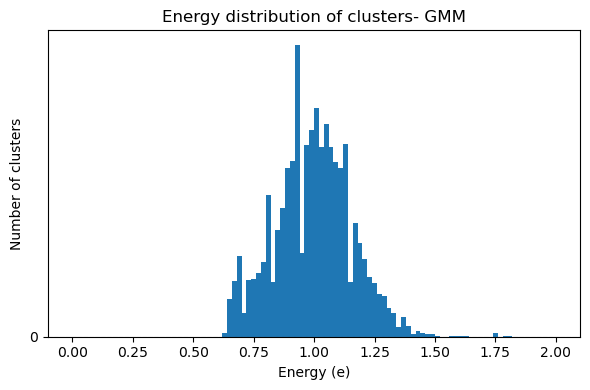

In [171]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=100, range=(0, 2))
# range=(0, 10)
plt.xlabel("Energy (e)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- GMM")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 500))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [172]:
import numpy as np
from scipy.ndimage import label as cc_label

def blobs_from_gmm(X_raw, gmm_labels, frame_size, cluster_id):
    """
    X_raw      : (N,3) array [y, x, E]
    gmm_labels : (N,) GMM labels (same order as X_raw)
    frame_size : (H, W)
    cluster_id : GMM component to extract

    Returns:
      blobs   : dict {blob_id: array [[y,x,E], ...]}
      labeled : (H,W) blob-ID image
    """
    H, W = frame_size

    sel = (gmm_labels == cluster_id)
    if not np.any(sel):
        labeled = np.zeros((H, W), dtype=int)
        return {}, labeled

    y = X_raw[sel, 0].astype(int)
    x = X_raw[sel, 1].astype(int)
    E = X_raw[sel, 2].astype(float)

    img = np.zeros((H, W), dtype=np.uint8)
    img[y, x] = 1

    # HARD-CODED 8-connectivity
    labeled = cc_label(img, structure=np.ones((3, 3), dtype=int))[0]

    blob_ids = labeled[y, x]
    blobs = {}

    for bid in np.unique(blob_ids):
        if bid == 0:
            continue
        m = (blob_ids == bid)
        blobs[bid] = np.column_stack([y[m], x[m], E[m]])  # [y,x,E]

    return blobs, labeled


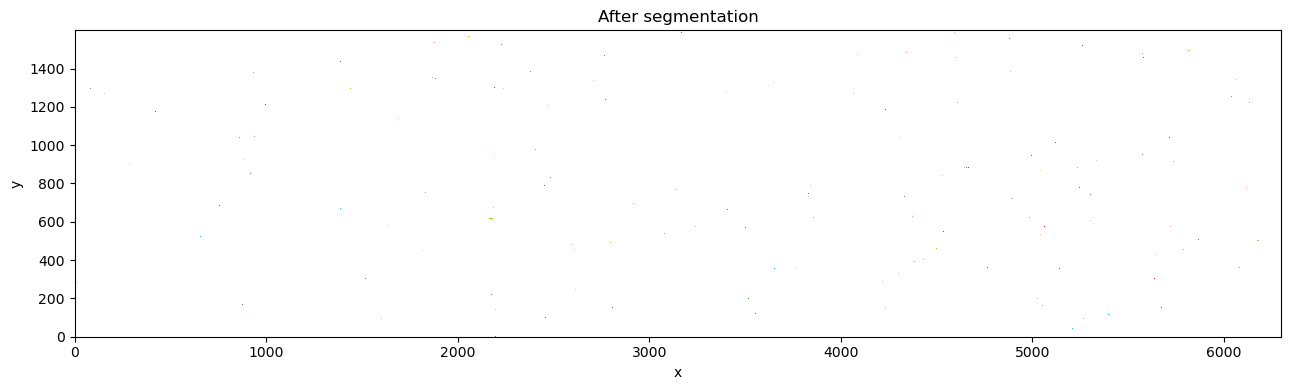

In [173]:
# build a colormap: 0 = white (background), blobs = colors
n_blobs = len(blobs)

colors = [(1, 1, 1, 1)]  # background = white
base = plt.cm.tab20.colors

for i in range(n_blobs):
    colors.append(base[i % len(base)])

cmap = ListedColormap(colors)

plt.figure(figsize=(24, 4))
plt.imshow(labeled, origin="lower", cmap=cmap, interpolation="none")
plt.title("After segmentation")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [105]:
df_blobs_without_singlepix = df_blobs[df_blobs['cluster_size'] > 1]

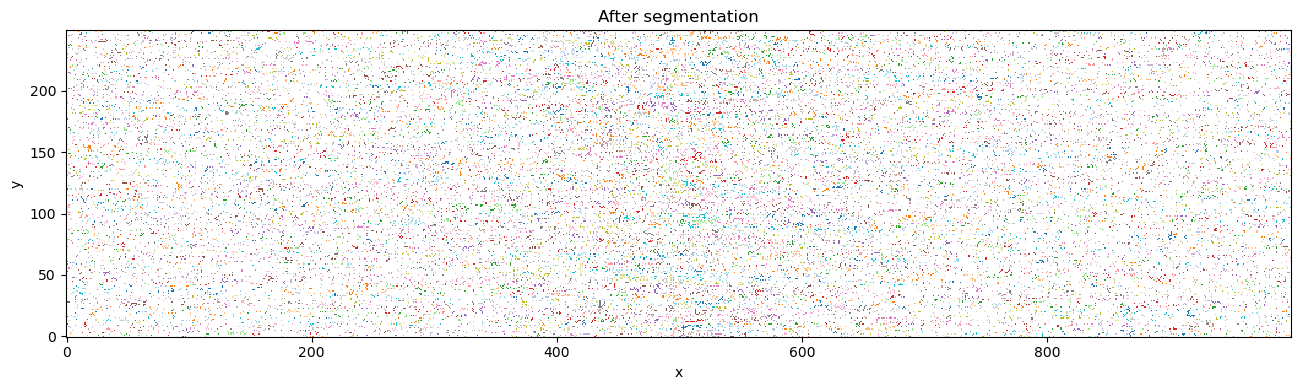

In [106]:
# build a colormap: 0 = white (background), blobs = colors
n_blobs = len(df_blobs_without_singlepix)

colors = [(1, 1, 1, 1)]  # background = white
base = plt.cm.tab20.colors

for i in range(n_blobs):
    colors.append(base[i % len(base)])

cmap = ListedColormap(colors)

plt.figure(figsize=(24, 4))
plt.imshow(labeled, origin="lower", cmap=cmap, interpolation="none")
plt.title("After segmentation")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

Most filled bin center: 1.214 keV


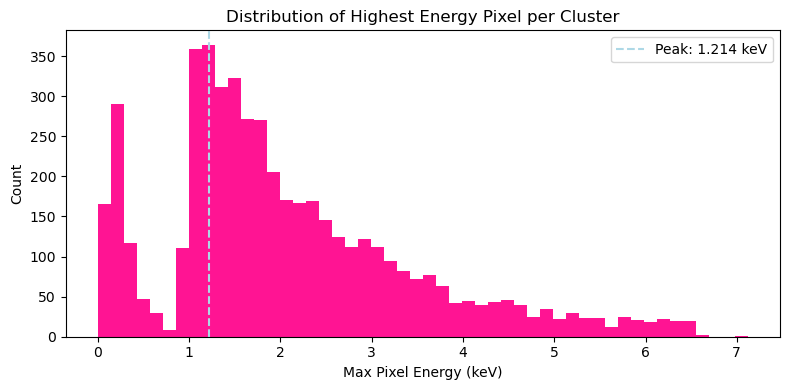

In [34]:
max_energies = df_blobs_without_singlepix['points'].apply(lambda pts: max(p[2] for p in pts))

counts, bin_edges = np.histogram(max_energies, bins=50)
peak_bin_center = (bin_edges[counts.argmax()] + bin_edges[counts.argmax() + 1]) / 2
print(f"Most filled bin center: {peak_bin_center:.3f} keV")

plt.figure(figsize=(8, 4))
plt.hist(max_energies, bins=50, color='deeppink', edgecolor='none')
plt.axvline(peak_bin_center, color='lightblue', linestyle='--', label=f'Peak: {peak_bin_center:.3f} keV')
plt.xlabel('Max Pixel Energy (keV)')
plt.ylabel('Count')
plt.title('Distribution of Highest Energy Pixel per Cluster')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
len(df_blobs_without_singlepix)

4935